# GPT-2 Training Replication Notebook

This notebook mainly adopted from
[https://github.com/karpathy/nanoGPT/tree/master](https://github.com/karpathy/nanoGPT/tree/master).

| Model | Date | Blog | Paper |
|-------|------|------|-------|
| GPT-1 | June 2018 | [Improving Language Understanding with Unsupervised Learning](https://openai.com/index/language-unsupervised/) | [Improving Language Understanding by Generative Pre-Training](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf) |
| GPT-2 | February 2019 | [Better Language Models and Their Implications](https://openai.com/index/better-language-models/) | [Language Models are Unsupervised Multitask Learners](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) |
| GPT-3 | May 2020 | [Language Models are Few-Shot Learners](https://openai.com/index/language-models-are-few-shot-learners/) | [Language Models are Few-Shot Learners](https://arxiv.org/pdf/2005.14165) |
| GPT-4 | March 2023 | [GPT-4](https://openai.com/index/gpt-4/) · [GPT-4 Research](https://openai.com/index/gpt-4-research/) | [GPT-4 Technical Report](https://arxiv.org/abs/2303.08774) |
| GPT-5 | August 2025 | [Introducing GPT-5](https://openai.com/index/introducing-gpt-5/) | [GPT-5 Technical Report](https://arxiv.org/abs/2601.03267) |

## 1. AR-LLMs (GPT-2) Generation

- In this jupyter notebook, we will train a GPT-2 model. Before we go, let us see the well-trained GPT-2 from OpenAI and check how to generate new sentences from it. Please figure it by yourself using uv to configure your own env.

In [1]:
import os
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")
warnings.filterwarnings("ignore")

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
# change it to your local folder if you are not using qz.cfff platform.
os.environ["HF_HOME"] = "/data/yc/llm-26-homework/hf_cache"
print(os.environ.get("HF_ENDPOINT"))

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import time

jnk_start_time = time.time()

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained("gpt2") 
# add the EOS token as PAD token to avoid warnings
model = AutoModelForCausalLM.from_pretrained(
    "gpt2", 
    pad_token_id=tokenizer.eos_token_id
).to(device)
print(model) # this gives you the model architecture and parameters.

https://hf-mirror.com


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


In [2]:
from torchinfo import summary

print("Generating model summary...")
summary(
    model, 
    input_size=(10, 128), 
    dtypes=[torch.long],  # CRITICAL: GPT-2 expects integers for token IDs, not floats
    device=device,
    col_names=("input_size", "output_size", "num_params", "params_percent")
)

Generating model summary...


Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Param %
GPT2LMHeadModel                                    [10, 128]                 --                        --                        -23.67%
├─GPT2Model: 1-1                                   [10, 128]                 --                        --                             --
│    └─Embedding: 2-1                              [10, 128]                 [10, 128, 768]            38,597,376                 23.67%
│    └─Embedding: 2-2                              [1, 128]                  [1, 128, 768]             786,432                     0.48%
│    └─Dropout: 2-3                                [10, 128, 768]            [10, 128, 768]            --                             --
│    └─ModuleList: 2-4                             --                        --                        --                             --
│    │    └─GPT2Block: 3-1               

### 1.1 Greedy Search

In [3]:
# encode context the generation is conditioned on
prompt = 'I enjoy walking with my cute dog'
model_inputs = tokenizer(prompt, return_tensors='pt').to(device)
print(model_inputs)
print(tokenizer.eos_token_id) # <|endoftext|>

# generate 40 new tokens
greedy_output = model.generate(
    **model_inputs,
    max_new_tokens=100,
    pad_token_id=tokenizer.eos_token_id
    )
print("Output: " + tokenizer.decode(greedy_output[0], skip_special_tokens=True))

{'input_ids': tensor([[   40,  2883,  6155,   351,   616, 13779,  3290]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]], device='cuda:0')}
50256
Output: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with my dog. I'm not sure if I'll ever be able to walk with my dog.

I'm not sure if I'll ever be able to walk with my dog. I'm not sure if I'll ever be able to walk with my dog.

I'm not sure if I'll ever be able to walk with my dog. I'm not sure if I'll ever be able to walk with my


**Hugging face use Greedy search by default. The output looks like repeating itself.**

### 1.2 Beam Search

In [4]:
# activate beam search and early_stopping
beam_output = model.generate(
    **model_inputs,
    max_new_tokens=100,
    num_beams=5,
    early_stopping=True,
    pad_token_id=tokenizer.eos_token_id
)
print("Output: " + tokenizer.decode(beam_output[0], skip_special_tokens=True))

Output: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever


**Beam search try to avoid local optima but still, the output looks like repeating itself.**

### 1.3 Beam Search with N-gram

In [5]:
# set no_repeat_ngram_size to 2
beam_output = model.generate(
    **model_inputs,
    max_new_tokens=100,
    num_beams=5,
    no_repeat_ngram_size=2,
    early_stopping=True,
    pad_token_id=tokenizer.eos_token_id
)

print("Output: " + tokenizer.decode(beam_output[0], skip_special_tokens=True))

Output: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I've been thinking about this for a while now, and I think it's time for me to take a step back and think about what I want to do next. I've always wanted to be a writer, so I thought I'd share my thoughts on how I would go about writing a book about my love of writing. Here are some of my favorite quotes from the book, as well as


**It seems that beam search with n-gram can avoid repeats. You can also generate multiple setencens as follows:**

In [6]:
# set return_num_sequences > 1
beam_outputs = model.generate(
    **model_inputs,
    max_new_tokens=40,
    num_beams=5,
    no_repeat_ngram_size=2,
    num_return_sequences=3,
    early_stopping=True,
    pad_token_id=tokenizer.eos_token_id
)

# now we have 3 output sequences
print("Output: ")
for i, beam_output in enumerate(beam_outputs):
    print("{}: {}".format(i, tokenizer.decode(beam_output, skip_special_tokens=True)))
    print('--')

Output: 
0: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I've been thinking about this for a while now, and I think it's time for me to
--
1: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with her again.

I've been thinking about this for a while now, and I think it's time for me to
--
2: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I've been thinking about this for a while now, and I think it's a good idea to
--


### 1.4 Pure Sampling (Standard Sampling)

In [7]:
# set seed to reproduce results. Feel free to change the seed though to get different results
from transformers import set_seed
set_seed(17)

# activate sampling and deactivate top_k by setting top_k = 0
sample_output = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_k=0, # the model is no longer picking the single best word (greedy decoding)
    pad_token_id=tokenizer.eos_token_id
)

print("Output: " +tokenizer.decode(sample_output[0], skip_special_tokens=True))

Output: I enjoy walking with my cute dog because when I see him I love it, the way his trunk and he's said to always take us out. We joke around and go outside and catch the sunrise.


Favorite episode is seeing


### 1.5 Standard sampling with temprature

By adding `temperature=0.6` while keeping `top_k=0`, you are still allowing the model to sample from the entire token vocabulary, but you are mathematically altering the odds before the die is rolled.  Before a language model outputs probabilities, its final layer produces raw scores called **logits** ($z$). To convert these raw logits into a proper probability distribution that sums to 1, the model passes them through a Softmax function. Temperature ($T$) is a divisor applied directly to those logits *before* the Softmax is calculated: $p_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$.

In [8]:
# use temperature to decrease the sensitivity to low probability candidates
sample_output = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_k=0,
    temperature=0.6,
    pad_token_id=tokenizer.eos_token_id
)

print("Output: " + tokenizer.decode(sample_output[0], skip_special_tokens=True))

Output: I enjoy walking with my cute dog and I like to play with my dog and I like to touch my dog."

His comments came as the council heard that one of the dogs, a dog named Arlene, had been rescued


### 1.6 Top-k Sampling

In [9]:
# set top_k to 50
sample_output = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_k=50,
    pad_token_id=tokenizer.eos_token_id
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(sample_output[0], skip_special_tokens=True))


Output:
----------------------------------------------------------------------------------------------------
I enjoy walking with my cute dog in that small cage and sometimes I get asked by my dog to climb up a wall and take a picture. Well, my dog did do this and has really gotten used to it. As long as


### 1.7 Top-k Sampling with temprature

In [10]:
# use temperature to decrease the sensitivity to low probability candidates
sample_output = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_k=50,
    temperature=0.6,
    pad_token_id=tokenizer.eos_token_id
)

print("Output: " + tokenizer.decode(sample_output[0], skip_special_tokens=True))

Output: I enjoy walking with my cute dog, but it's too hard to keep my dog. We love to play, and when we can't, we're happy.

There are a lot of ways to make your dog happy –


### 1.8 Top-p (nucleus) sampling

In [11]:
# set top_k to 50
sample_output = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_p=0.92,
    top_k=0,
    pad_token_id=tokenizer.eos_token_id
)

print("Output: " + tokenizer.decode(sample_output[0], skip_special_tokens=True))

Output: I enjoy walking with my cute dog behind our wall, yes, we were going to have some fun, but it was this knotted mess we were riding, so our kid let us at least have our first day, and had a


In [12]:
# set top_k = 50 and set top_p = 0.95 and num_return_sequences = 3
sample_outputs = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_k=50,
    top_p=0.95,
    num_return_sequences=3,
    pad_token_id=tokenizer.eos_token_id
)

print("Output: ")

for i, sample_output in enumerate(sample_outputs):
    print("{}: {}".format(i, tokenizer.decode(sample_output, skip_special_tokens=True)))
    print('--')

Output: 
0: I enjoy walking with my cute dog. We play with the kids with my dog, get to know them. At this point I started to see my dog and started asking him if I knew anything and it just stuck. I don't
--
1: I enjoy walking with my cute dog. I've never had her treat us like shit!" In the end, it was the two of them that were the first to notice she was alive.

In the end, it's safe
--
2: I enjoy walking with my cute dog, and have made my dog walk with the most wonderful people around him (the owner was the husband I'm still with, I just love his dogs so much). I'm going to be living with
--


### 1.9 Most practical use

In [13]:
sample_outputs = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_k=50,
    top_p=0.95,
    temperature=0.7,             # Highly recommended for GPT models
    num_return_sequences=3,
    pad_token_id=tokenizer.eos_token_id,
    repetition_penalty=1.2       # Optional: Prevents the model from getting stuck in a loop
)
print("Output: ")

for i, sample_output in enumerate(sample_outputs):
    print("{}: {}".format(i, tokenizer.decode(sample_output, skip_special_tokens=True)))
    print('--')

Output: 
0: I enjoy walking with my cute dog and playing at the pool, but I'm also not a huge fan of drinking. And while it's true that most people won't have drinks when they're older (especially in New York), there
--
1: I enjoy walking with my cute dog, the big white one. I love to play and talk about how awesome it is when we have a good time."
"The biggest thing you learn in life can be that your greatest fear isn
--
2: I enjoy walking with my cute dog, but I know that there is much more to do.
If you're looking for some great local food trucks or fun activities and are feeling adventurous in your travels (and have a pet) check
--


## 2. Try to replicate GPT2 from scratch

### 2.1 Check Transformer model and GPT-2 model

Loaded the pretrained GPT-2 model from the Hugging Face transformers. The original code of GPT-2 and its models are written in Tensorflow, which is not popular any more. We would like to choose to use Huggingface Transformers.

- [https://github.com/huggingface/transformers/blob/main/src/transformers/models/gpt2/modeling_gpt2.py](https://github.com/huggingface/transformers/blob/main/src/transformers/models/gpt2/modeling_gpt2.py)
- [https://huggingface.co/openai-community/gpt2](https://huggingface.co/openai-community/gpt2)

In [14]:
from transformers import GPT2LMHeadModel
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") # 
sd_hf = model_hf.state_dict()
for k, v in sd_hf.items():
    print(k, v.shape)
print(sd_hf['transformer.wpe.weight'])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

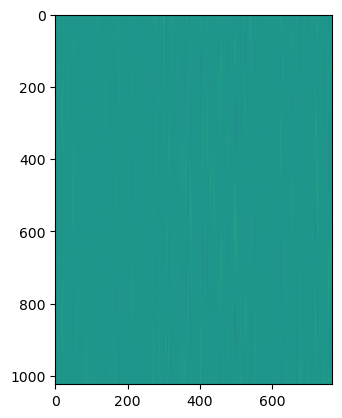

In [15]:
import matplotlib.pyplot as plt
%matplotlib inline
# positional encoding for the first token
plt.imshow(sd_hf['transformer.wpe.weight'])
plt.show()

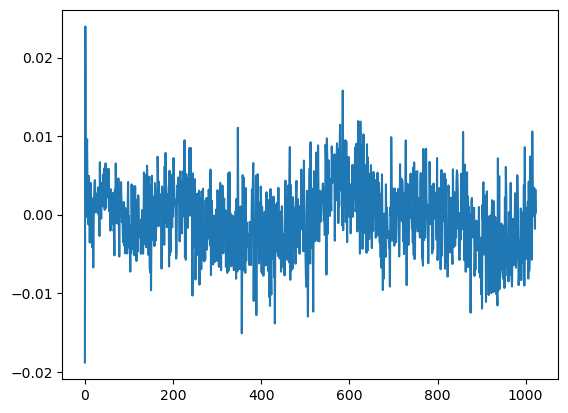

In [16]:
# positional encoding for the first token
plt.plot(sd_hf['transformer.wpe.weight'][:, 0])
plt.show()

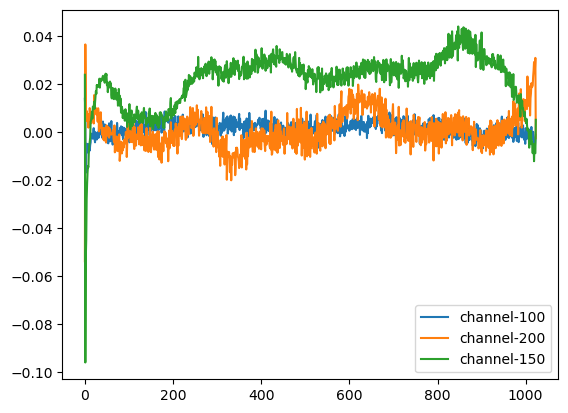

In [17]:
plt.plot(sd_hf['transformer.wpe.weight'][:, 100], label='channel-100')
plt.plot(sd_hf['transformer.wpe.weight'][:, 200], label='channel-200')
plt.plot(sd_hf['transformer.wpe.weight'][:, 250], label='channel-150')
plt.legend()
plt.show()

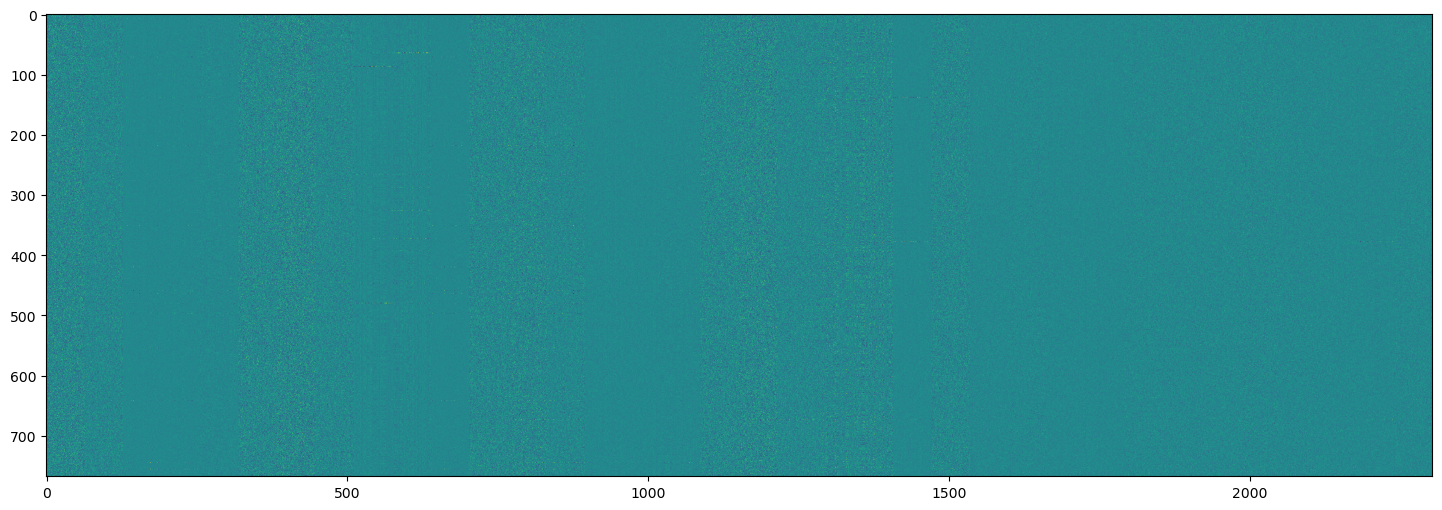

In [18]:
fig, ax = plt.subplots(figsize=(18, 6))
ax.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"])
plt.show()

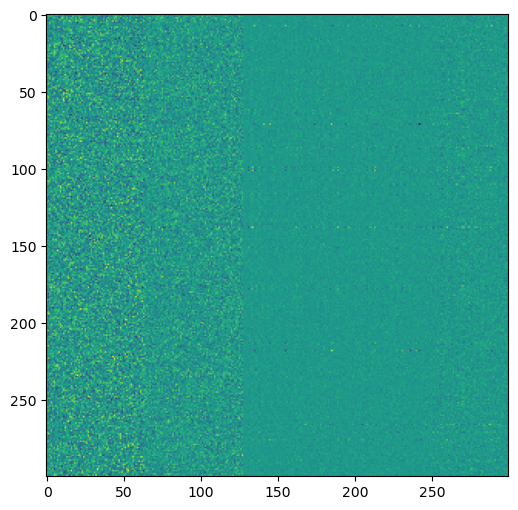

In [19]:
fig, ax = plt.subplots(figsize=(18, 6))
ax.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300,:300])
plt.show()

**generating sentence from GPT-2 model.**

In [20]:
from transformers import AutoModel
from transformers import pipeline, set_seed

set_seed(17)
# 1. Just load the pipeline. It will handle loading the model & tokenizer automatically.
generator = pipeline('text-generation', model='gpt2')
# 2. Pass the RAW string to the generator.
output = generator(
    "I love Fudan,", 
    max_new_tokens=50,    # How many words to add
    truncation=True,      # Cleanly handle long inputs
    pad_token_id=50256    # Stops the "Setting pad_token_id" warning
)
for i, o in enumerate(output):
    print(f"[{i}] {o['generated_text']}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[0] I love Fudan, and when I see it in the UK, I don't think I've seen a better restaurant."

He says one of the reasons his son's favourite place is Fudan is because of the food and the atmosphere.

"When


GPT-2 architecture:

- GPT class ([nn.ModuleDict](https://pytorch.org/docs/stable/generated/torch.nn.ModuleDict.html), [nn.Embedding](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html), [nn.ModuleList](https://pytorch.org/docs/stable/generated/torch.nn.ModuleList.html), [nn.LayerNorm](https://pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html))
- Block class (CausalSelfAttention, LayerNorm, MLP)
- CausalSelfAttention class (Dropout, nn.Linear)
- MLP class (nn.Linear, nn.GELU, nn.Dropout)

**Please check GPT-2 v1 code**

### 3.2 Load GPT-2 from source code

In [21]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F

In [22]:
class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias) # matrix of W1
        # GELU paper: https://arxiv.org/pdf/1606.08415
        self.gelu    = nn.GELU() # nonlinear activation function
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias) # matrix of W2

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x

In [23]:
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        # This line creates a lower triangular attention mask (often called a causal mask) 
        # and registers it as a buffer inside your PyTorch model (not as a parameter).
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y

In [24]:
class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

In [25]:
@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50257
    bias: bool = True
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte = nn.Embedding(config.vocab_size, config.n_embd),
                wpe = nn.Embedding(config.block_size, config.n_embd),
                h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f = nn.LayerNorm(config.n_embd),
            )
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)


    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        """Loads pretrained GPT-2 model weights from huggingface. """
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

model= GPT.from_pretrained('gpt2')
print('Successfully load the model from GPT-2 to ours!')

loading weights from pretrained gpt: gpt2
forcing vocab_size=50257, block_size=1024, bias=True


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Successfully load the model from GPT-2 to ours!


### 3.3 Sampling from GTP-2 initial

- Adding forward for GPT class
- Add tiktoken for tokenization
- Top-k sampling algorithm

In [26]:
from transformers import GPT2LMHeadModel
# Choose your model_type, e.g., 'gpt2'
model_type = 'gpt2' 
model_hf = GPT2LMHeadModel.from_pretrained(model_type)
model_hf.save_pretrained(f"./{model_type}_weights")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [27]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50257
    bias: bool = True
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte = nn.Embedding(config.vocab_size, config.n_embd),
                wpe = nn.Embedding(config.block_size, config.n_embd),
                h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f = nn.LayerNorm(config.n_embd),
            )
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    def forward(self, idx, targets=None):
        b, t = idx.size() # (B, T)
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = tok_emb + pos_emb
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        return logits


    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        """Loads pretrained GPT-2 model weights from huggingface. """
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(f"./{model_type}_weights")
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

In [28]:
num_return_sequences = 5
max_length = 30
model = GPT.from_pretrained('gpt2')
model.eval()
model.to('cuda')

loading weights from pretrained gpt: gpt2
forcing vocab_size=50257, block_size=1024, bias=True


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (h): ModuleList(
      (0-11): 12 x Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=768, out_features=2304, bias=True)
          (c_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='none')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [29]:
from transformers import GPT2Tokenizer
# Point it to your local directory
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2_weights")
tokens = tokenizer.encode("Hello, I'm a language model,")
print(tokens)
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1) # (5,8)
x = tokens.to('cuda')


[15496, 11, 314, 1101, 257, 3303, 2746, 11]


In [30]:
import math 
# generate! right now x is (B, T) where B = 5, T = 8
# set the seed to 42
device = 'cuda'
torch.manual_seed(42)
# torch.cuda.manual_seed(42)
print(x.size(1), max_length)
while x.size(1) < max_length:
    # forward the model to get the logits
    with torch.no_grad():
        logits = model(x) # (B, T, vocab_size)
        # take the logits at the last position
        logits = logits[:, -1, :] # (B, vocab_size)
        # get the probabilities
        probs = F.softmax(logits, dim=-1)
        # do top-k sampling of 50 (huggingface pipeline default)
        # topk_probs here becomes (5, 50), topk_indices is (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
        print(probs.shape, topk_probs.shape, topk_probs[0,:].sum())
        # select a token from the top-k probabilities
        ix = torch.multinomial(topk_probs, 1) # (B, 1)
        # gather the corresponding indices
        xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
        # append to the sequence
        x = torch.cat((x, xcol), dim=1)
        print(x.shape)

for i in range(num_return_sequences):
    tokens = x[i, :max_length].tolist()
    decoded = tokenizer.decode(tokens)
    print(">", decoded)

8 30
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.8060, device='cuda:0')
torch.Size([5, 9])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.9104, device='cuda:0')
torch.Size([5, 10])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.5246, device='cuda:0')
torch.Size([5, 11])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.8912, device='cuda:0')
torch.Size([5, 12])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.8049, device='cuda:0')
torch.Size([5, 13])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.9985, device='cuda:0')
torch.Size([5, 14])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.5723, device='cuda:0')
torch.Size([5, 15])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.8651, device='cuda:0')
torch.Size([5, 16])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.6959, device='cuda:0')
torch.Size([5, 17])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.9391, device='cuda:0')
torch.Size([5, 18])
torch.Size([5, 50257]) torch.Size([5, 50]) ten

### 3.4 Sampling from random model

- We only need to change the code code from

```python
  model = GPT.from_pretrained('gpt2')
```
into
```python
  model = GPT(GPTConfig())
```

In [31]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F
from transformers import GPT2Tokenizer

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias) # matrix of W1
        # GELU paper: https://arxiv.org/pdf/1606.08415
        self.gelu    = nn.GELU() # nonlinear activation function
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias) # matrix of W2

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x
        
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50257
    bias: bool = True
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte = nn.Embedding(config.vocab_size, config.n_embd),
                wpe = nn.Embedding(config.block_size, config.n_embd),
                h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f = nn.LayerNorm(config.n_embd),
            )
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    def forward(self, idx, targets=None):
        b, t = idx.size() # (B, T)
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = tok_emb + pos_emb
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        return logits


    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        """Loads pretrained GPT-2 model weights from huggingface. """
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

num_return_sequences = 5
max_length = 30
model = GPT(GPTConfig())
model.eval()
model.to('cuda')
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2_weights")

tokens = tokenizer.encode("Hello, I'am a language model,")
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1) # (5,8)
# x = tokens.to('cuda')
x = tokens.to('cuda')  # change to GPU, if you have any.

device = 'cuda'
torch.manual_seed(42)
# torch.cuda.manual_seed(42)
print(x.size(1), max_length)
while x.size(1) < max_length:
    # forward the model to get the logits
    with torch.no_grad():
        logits = model(x) # (B, T, vocab_size)
        # take the logits at the last position
        logits = logits[:, -1, :] # (B, vocab_size)
        # get the probabilities
        probs = F.softmax(logits, dim=-1)
        # do top-k sampling of 50 (huggingface pipeline default)
        # topk_probs here becomes (5, 50), topk_indices is (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
        print(probs.shape, topk_probs.shape, topk_probs[0,:].sum())
        # select a token from the top-k probabilities
        ix = torch.multinomial(topk_probs, 1) # (B, 1)
        # gather the corresponding indices
        xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
        # append to the sequence
        x = torch.cat((x, xcol), dim=1)

for i in range(num_return_sequences):
    tokens = x[i, :max_length].tolist()
    decoded = tokenizer.decode(tokens)
    print(">", decoded)


9 30
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0061, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0059, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0058, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0062, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0058, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0056, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0061, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0061, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0059, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0061, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0064, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0057, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0061, device='cuda:0')
torch.Size([5, 50257

## 3. Train GPT-2 model using Shakespeare dataset

In [32]:
# read it in to inspect it
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()
data = text[:200]
print(data)

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [33]:
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2_weights")
tokens = tokenizer.encode(data)
print(tokens[:24])
buf = torch.tensor(tokens[:24])
x = buf.view(4, 6)
print(x)

[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]
tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])


In [34]:
# data sample x and label y
buf = torch.tensor(tokens[:24 + 1])
x = buf[:-1].view(4, 6)
y = buf[1:].view(4, 6)
print(x)
print(y)

tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])
tensor([[22307,    25,   198,  8421,   356,  5120],
        [  597,  2252,    11,  3285,   502,  2740],
        [   13,   198,   198,  3237,    25,   198],
        [ 5248,   461,    11,  2740,    13,   198]])


### 3.1 Form a batch and put it into GPT-2 and then output logits

In [35]:
import math
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F
from transformers import GPT2Tokenizer


class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias) # matrix of W1
        # GELU paper: https://arxiv.org/pdf/1606.08415
        self.gelu    = nn.GELU() # nonlinear activation function
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias) # matrix of W2

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x
        
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50257
    bias: bool = True
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte = nn.Embedding(config.vocab_size, config.n_embd),
                wpe = nn.Embedding(config.block_size, config.n_embd),
                h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f = nn.LayerNorm(config.n_embd),
            )
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    def forward(self, idx, targets=None):
        b, t = idx.size() # (B, T)
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = tok_emb + pos_emb
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss


    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        """Loads pretrained GPT-2 model weights from huggingface. """
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

# attempt to autodetect the device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

num_return_sequences = 5
max_length = 30
model = GPT(GPTConfig())
model.eval()
model.to(device)

import math
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2_weights")
tokens = tokenizer.encode("Hello, I'am a language model,")
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1) # (5,8)
# x = tokens.to('cuda')
x = tokens.to(device)

print(f"using device: {device}")
with open('input.txt', 'r') as f:
    text = f.read()
text = text[:1000]
tokens = tokenizer.encode(text)
B, T = 4, 32
buf = torch.tensor(tokens[:B*T + 1])
x = buf[:-1].view(B, T).to(device)  # ← move to device
y = buf[1:].view(B, T).to(device)   # ← move to device
# get logits
model = GPT(GPTConfig())
model.to(device)
logits, loss = model(x)
print(logits.shape, loss)

logits, loss = model(x, y)
print(logits.shape, loss)

using device: cuda
torch.Size([4, 32, 50257]) None
torch.Size([4, 32, 50257]) tensor(11.0398, device='cuda:0', grad_fn=<NllLossBackward0>)


**get loss**

In [36]:
import numpy as np
print(np.log(1/50257.))

-10.82490511970208


### 3.2 Training the model via AdamW single batch

In [37]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias) # matrix of W1
        # GELU paper: https://arxiv.org/pdf/1606.08415
        self.gelu    = nn.GELU() # nonlinear activation function
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias) # matrix of W2

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x
        
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50257
    bias: bool = True
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte = nn.Embedding(config.vocab_size, config.n_embd),
                wpe = nn.Embedding(config.block_size, config.n_embd),
                h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f = nn.LayerNorm(config.n_embd),
            )
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    def forward(self, idx, targets=None):
        b, t = idx.size() # (B, T)
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = tok_emb + pos_emb
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss


    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        """Loads pretrained GPT-2 model weights from huggingface. """
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

num_return_sequences = 5
max_length = 30
model = GPT(GPTConfig())
model.eval()
model.to('cuda')

import math
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2_weights")
tokens = tokenizer.encode("Hello, I'am a language model,")
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1) # (5,8)
x = tokens.to('cuda')

# attempt to autodetect the device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")
device = "cuda" # OVERRIDE
with open('input.txt', 'r') as f:
    text = f.read()
text = text[:1000]
tokens = tokenizer.encode(text)
B, T = 4, 32
buf = torch.tensor(tokens[:B*T + 1])
buf = buf.to(device)
x = buf[:-1].view(B, T)
y = buf[1:].view(B, T)
# get logits
model = GPT(GPTConfig())
model.to(device)
logits, loss = model(x)
print(logits.shape, loss)

logits, loss = model(x, y)
print(logits.shape, loss)

# get logits
model = GPT(GPTConfig())
model.to(device)
# optimize!
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
loss_hist = []
for i in range(50):
    optimizer.zero_grad()
    logits, loss = model(x, y)
    loss.backward()
    optimizer.step()
    print(f"step {i}, loss: {loss.item()}")
    loss_hist.append(loss.item())

using device: cuda
torch.Size([4, 32, 50257]) None
torch.Size([4, 32, 50257]) tensor(10.9952, device='cuda:0', grad_fn=<NllLossBackward0>)
step 0, loss: 11.030731201171875
step 1, loss: 6.652603626251221
step 2, loss: 4.296859264373779
step 3, loss: 2.5828962326049805
step 4, loss: 1.4670884609222412
step 5, loss: 0.821276068687439
step 6, loss: 0.4625840187072754
step 7, loss: 0.2776137888431549
step 8, loss: 0.18143115937709808
step 9, loss: 0.11646316200494766
step 10, loss: 0.07955800741910934
step 11, loss: 0.05930355563759804
step 12, loss: 0.04392475634813309
step 13, loss: 0.0353439599275589
step 14, loss: 0.030815700069069862
step 15, loss: 0.027093393728137016
step 16, loss: 0.023468706756830215
step 17, loss: 0.020153015851974487
step 18, loss: 0.017465103417634964
step 19, loss: 0.015461103990674019
step 20, loss: 0.013876138255000114
step 21, loss: 0.01251177303493023
step 22, loss: 0.011295401491224766
step 23, loss: 0.010226689279079437
step 24, loss: 0.00931201409548521

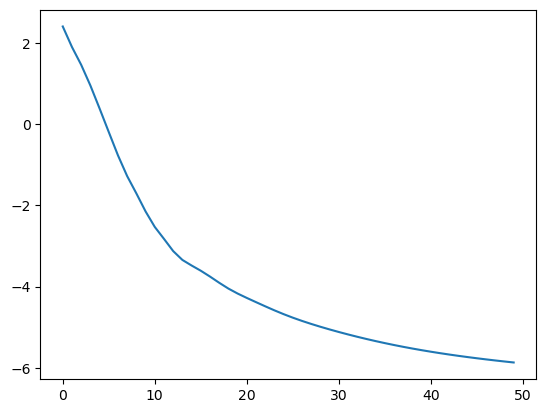

In [38]:
plt.plot(np.log(loss_hist))
plt.show()

**The model is overfitting the single batch!**

### 3.3 Embedding and Unembedding sharing

In [39]:
print(sd_hf["lm_head.weight"].shape)
print(sd_hf["transformer.wte.weight"].shape)

torch.Size([50257, 768])
torch.Size([50257, 768])


In [40]:
(sd_hf["lm_head.weight"] == sd_hf["transformer.wte.weight"]).all()

tensor(True)

In [41]:
print(sd_hf["lm_head.weight"].data_ptr())
print(sd_hf["transformer.wte.weight"].data_ptr())

140510012288979
140510012288979


**[https://github.com/openai/gpt-2/blob/master/src/model.py embedding model line 154](https://github.com/openai/gpt-2/blob/master/src/model.py)**

**[https://github.com/openai/gpt-2/blob/master/src/model.py unembedding model line 171](https://github.com/openai/gpt-2/blob/master/src/model.py)**

In [42]:
from dataclasses import dataclass
import torch
import math
import torch.nn as nn
from torch.nn import functional as F
from transformers import GPT2Tokenizer


class DataLoaderLite:
    def __init__(self, B, T):
        self.B = B
        self.T = T
        # at init load tokens from disk and store them in memory
        with open('input.txt', 'r') as f:
            text = f.read()
        tokenizer = GPT2Tokenizer.from_pretrained("./gpt2_weights")
        tokens = tokenizer.encode(text)
        self.tokens = torch.tensor(tokens)
        print(f"loaded {len(self.tokens)} tokens")
        print(f"1 epoch = {len(self.tokens) // (B * T)} batches")
        # state
        self.current_position = 0
        
    def next_batch(self):
        B, T = self.B, self.T
        buf = self.tokens[self.current_position : self.current_position+B*T+1]
        x = (buf[:-1]).view(B, T) # inputs
        y = (buf[1:]).view(B, T) # targets
        # advance the position in the tensor
        self.current_position += B * T
        # if loading the next batch would be out of bounds, reset
        if self.current_position + (B * T + 1) > len(self.tokens):
            self.current_position = 0
        return x, y

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias) # matrix of W1
        # GELU paper: https://arxiv.org/pdf/1606.08415
        self.gelu    = nn.GELU() # nonlinear activation function
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias) # matrix of W2

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x
        
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.c_proj.NANOGPT_SCALE_INIT = 1
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50257
    bias: bool = True
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte = nn.Embedding(config.vocab_size, config.n_embd),
                wpe = nn.Embedding(config.block_size, config.n_embd),
                h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f = nn.LayerNorm(config.n_embd),
            )
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # weight sharing scheme
        self.transformer.wte.weight = self.lm_head.weight

        # init params
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.02
            if hasattr(module, 'NANOGPT_SCALE_INIT'):
                std *= (2 * self.config.n_layer) ** -0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)


    def forward(self, idx, targets=None):
        b, t = idx.size() # (B, T)
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = tok_emb + pos_emb
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss


    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        """Loads pretrained GPT-2 model weights from huggingface. """
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

# attempt to autodetect the device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")

train_loader = DataLoaderLite(B=4, T=32)

# get logits
model = GPT(GPTConfig())
model.to(device)
# optimize!
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
hist_loss = []
for i in range(800):
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)  # ← add this line
    optimizer.zero_grad()
    logits, loss = model(x, y)
    loss.backward()
    optimizer.step()
    print(f"step {i}, loss: {loss.item()}")
    hist_loss.append(loss.item())

using device: cuda
loaded 338025 tokens
1 epoch = 2640 batches
step 0, loss: 10.937108993530273
step 1, loss: 9.627819061279297
step 2, loss: 8.807690620422363
step 3, loss: 9.230671882629395
step 4, loss: 8.657054901123047
step 5, loss: 8.40292739868164
step 6, loss: 9.032166481018066
step 7, loss: 8.743717193603516
step 8, loss: 8.219195365905762
step 9, loss: 7.949550628662109
step 10, loss: 8.338224411010742
step 11, loss: 7.45030403137207
step 12, loss: 7.826913833618164
step 13, loss: 7.495353698730469
step 14, loss: 7.548830032348633
step 15, loss: 7.426259517669678
step 16, loss: 7.418711185455322
step 17, loss: 8.315892219543457
step 18, loss: 7.206585884094238
step 19, loss: 7.807531356811523
step 20, loss: 7.417864799499512
step 21, loss: 7.80742073059082
step 22, loss: 6.375888824462891
step 23, loss: 6.791141033172607
step 24, loss: 6.837495803833008
step 25, loss: 6.494931221008301
step 26, loss: 6.561034202575684
step 27, loss: 7.5964508056640625
step 28, loss: 7.0348892

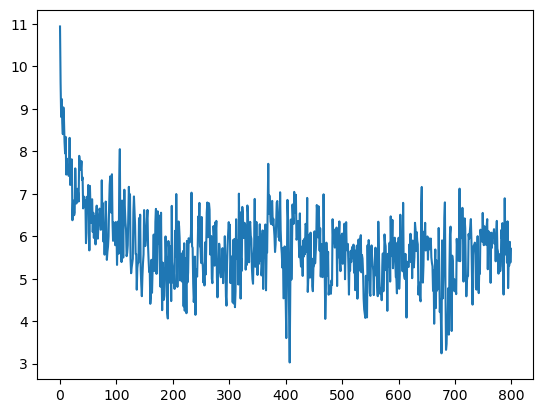

In [43]:
plt.plot(hist_loss)
plt.show()

In [44]:
!time python train_gpt2_multi_epoch.py

using device: cuda
loaded 338025 tokens
1 epoch = 2640 batches
/data/yc/miniconda/envs/llm-26-gpu/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:322: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
/data/yc/miniconda/envs/llm-26-gpu/lib/python3.12/site-packages/torch/_inductor/lowering.py:7836: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(
step 0, loss: 11.025663375854492
step 1, loss: 9.679655075073242
step 2, loss: 8.874646186828613
step 3, loss: 9.026905059814453
step 4, loss: 8.768091201782227
step 5, loss: 8.327535629272461
step 6, loss: 8.915167808532715
step 7, loss: 8.74862289428711
step 8, loss: 8.117717742919922
step 9, loss: 7.881485939

### 3.4 FlashAttention

**To speedup the multi head attention, one can apply [flash attention](https://arxiv.org/abs/2205.14135).**

In [45]:
!time python train_gpt2_flash_attention.py

using device: cuda
loaded 338025 tokens
1 epoch = 2640 batches
step 0, loss: 10.974703788757324
step 1, loss: 9.641982078552246
step 2, loss: 8.825291633605957
step 3, loss: 9.078409194946289
step 4, loss: 8.773382186889648
step 5, loss: 8.275269508361816
step 6, loss: 9.052999496459961
step 7, loss: 8.726430892944336
step 8, loss: 8.134296417236328
step 9, loss: 7.967275619506836
step 10, loss: 8.465576171875
step 11, loss: 7.483943939208984
step 12, loss: 7.804881572723389
step 13, loss: 7.325818061828613
step 14, loss: 7.576128959655762
step 15, loss: 7.345211029052734
step 16, loss: 7.421976566314697
step 17, loss: 8.157087326049805
step 18, loss: 7.169146537780762
step 19, loss: 7.80683708190918
step 20, loss: 7.501727104187012
step 21, loss: 7.766689300537109
step 22, loss: 6.499548435211182
step 23, loss: 6.804682731628418
step 24, loss: 6.847927570343018
step 25, loss: 6.652888774871826
step 26, loss: 6.778200149536133
step 27, loss: 7.580244064331055
step 28, loss: 7.163398742

### 3.5 Dynamic Learning rate Schedule

In [46]:
!time python train_gpt2_dynamic_lr.py

using device: cuda
loaded 338025 tokens
1 epoch = 20 batches
step    0 | loss: 10.947359 | lr 6.0000e-05 | norm: 28.5704 | dt: 21110.78ms | tok/sec: 776.10
step    1 | loss: 9.502584 | lr 1.2000e-04 | norm: 10.6507 | dt: 255.85ms | tok/sec: 64038.04
step    2 | loss: 9.249987 | lr 1.8000e-04 | norm: 7.3203 | dt: 257.23ms | tok/sec: 63695.20
step    3 | loss: 9.762202 | lr 2.4000e-04 | norm: 6.6695 | dt: 256.25ms | tok/sec: 63936.34
step    4 | loss: 9.104456 | lr 3.0000e-04 | norm: 4.2461 | dt: 259.29ms | tok/sec: 63187.07
step    5 | loss: 8.794599 | lr 3.6000e-04 | norm: 3.2611 | dt: 257.14ms | tok/sec: 63716.46
step    6 | loss: 8.586369 | lr 4.2000e-04 | norm: 2.3769 | dt: 256.81ms | tok/sec: 63797.03
step    7 | loss: 8.265532 | lr 4.8000e-04 | norm: 2.0555 | dt: 255.45ms | tok/sec: 64137.08
step    8 | loss: 7.887897 | lr 5.4000e-04 | norm: 2.2157 | dt: 257.27ms | tok/sec: 63683.16
step    9 | loss: 7.519876 | lr 6.0000e-04 | norm: 2.1506 | dt: 257.40ms | tok/sec: 63651.60
step  

## 4. Train GPT-2 using fineweb-edu dataset

### 4.1 Loadset

- We will use [https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu](https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu) for training a GPT-2 model.
- Paper [The FineWeb Datasets: Decanting the Web for the Finest Text Data at Scale](https://arxiv.org/pdf/2406.17557)
- **sample-10BT**: a subset randomly sampled from the whole dataset of around 10B gpt2 tokens
- **downloaded**: we already downloaded at global_public/datasets-models/lecture-06-gpts-edu_fineweb10B

### 4.2 Training GPT-2 on GPU

Then run the following command: ``` python train_gpt2.py ```
If the B=64 (batch size is too large, just let it be 32 or 16).

In [47]:
!time python train_gpt2.py

using device: cuda
total desired batch size: 524288
=> calculated gradient accumulation steps: 8
Traceback (most recent call last):
  File "/data/yc/llm-26-homework/train_gpt2.py", line 489, in <module>
    main()
  File "/data/yc/llm-26-homework/train_gpt2.py", line 320, in main
    train_loader = DataLoaderLite(B=B, T=T, process_rank=ddp_rank, num_processes=ddp_world_size, split="train", master_process=master_process)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/data/yc/llm-26-homework/train_gpt2.py", line 229, in __init__
    shards = os.listdir(data_root)
             ^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/inspire/hdd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_public/datasets-models/lecture-06-gpts-edu_fineweb10B'

real	0m7.262s
user	0m22.381s
sys	0m1.148s


### 4.3 Evaluation on [HellaSWAG](https://arxiv.org/abs/1905.07830)

Run the following command:

```python
python hellaswag.py
```

In [48]:
!time python hellaswag.py

Loading weights: 100%|██████████████████████| 148/148 [00:00<00:00, 9742.10it/s]
1 acc_norm: 0/1=0.0000
---
Context:
 A man is sitting on a roof. he
Endings:
0 (loss: 3.9474) is using wrap to wrap a pair of skis.
1 (loss: 5.7732) is ripping level tiles off.
2 (loss: 2.9486) is holding a rubik's cube.
3 (loss: 4.0702) starts pulling up roofing on a roof.
predicted: 2, actual: 3
2 acc_norm: 0/2=0.0000
---
Context:
 A lady walks to a barbell. She bends down and grabs the pole. the lady
Endings:
0 (loss: 3.6541) swings and lands in her arms.
1 (loss: 2.5001) pulls the barbell forward.
2 (loss: 2.3630) pulls a rope attached to the barbell.
3 (loss: 2.8399) stands and lifts the weight over her head.
predicted: 2, actual: 3
3 acc_norm: 1/3=0.3333
---
Context:
 Two women in a child are shown in a canoe while a man pulls the canoe while standing in the water, with other individuals visible in the background. the child and a different man
Endings:
0 (loss: 2.9822) are then shown paddling down a 

In [49]:
# Finally, you all done! Please submit your jupyter notebook via elearning!
your_chinese_name = "杨晨" # put your chinese name here
your_student_id = "25210980120" # put your student id here

jnk_end_time = time.time()
total = jnk_end_time - jnk_start_time
h, rem = divmod(int(total), 3600)
m, s = divmod(rem, 60)

print(f"Total runtime: {h} h {m} min {s} s")
print(f"I am {your_chinese_name}:{your_student_id}, I am doing a great job!")

Total runtime: 0 h 18 min 5 s
I am 杨晨:25210980120, I am doing a great job!


- **save your work as html file.

In [50]:
!jupyter nbconvert lecture-06-gpts-25210980120-杨晨.ipynb --to html --template classic --embed-images

[NbConvertApp] Converting notebook lecture-06-gpts-25210980120-杨晨.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 2859664 bytes to lecture-06-gpts-25210980120-杨晨.html
